# Feature Engineering Pipeline

End-to-end PySpark pipeline for network traffic classification:
- Label encoding → Feature assembly → Scaling → Random Forest feature selection → Pipeline serialization

**Models saved to `models/`:**
| File | Description |
|------|-------------|
| `string_indexer` | Fitted StringIndexer for Label → label_index |
| `scaler_all_features` | StandardScaler fitted on all 58 features |
| `scaler_good_features` | StandardScaler fitted on 56 variance-filtered features |
| `rf_selector` | RandomForest model used for feature importance |
| `scaler_selected_features` | StandardScaler fitted on final 40 features |
| `feature_pipeline` | Full inference pipeline (indexer + assembler + scaler) |
| `selected_features.pkl` | Python list of the 40 selected feature names |

## 1. Setup & Imports

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
from pyspark.sql import functions as F
import time
import os
import pickle
from pyspark.sql.functions import (
    col, when, to_date, year, month, dayofmonth,
    trim, lower, round as spark_round, avg, count
)
import matplotlib.pyplot as plt
import numpy as np

In [4]:
import time
import os
import shutil
from pyspark.sql import SparkSession

# ============================================
# SETUP
# ============================================
try:
    spark.stop()
except:
    pass

spark = (
    SparkSession.builder
    .appName("high-performance-local-spark")
    .master("local[24]")
    .config("spark.driver.memory", "180g")
    .config("spark.driver.maxResultSize", "20g")
    .config("spark.sql.shuffle.partitions", "96")
    .config("spark.default.parallelism", "96")
    .config("spark.memory.fraction", "0.75")
    .config("spark.memory.storageFraction", "0.3")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.adaptive.skewJoin.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
# Verify configuration
print(f"Driver Memory: {spark.conf.get('spark.driver.memory')}")
print(f"Shuffle Partitions: {spark.conf.get('spark.sql.shuffle.partitions')}")
print(f"Master URL: {spark.conf.get('spark.master')}")


Driver Memory: 180g
Shuffle Partitions: 96
Master URL: local[24]


26/05/03 02:29:28 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## 2. Load & Cache Data

In [5]:
df = spark.read.parquet("data/clean/")

## 3. Train / Holdout Split

Reserve **15%** as a streaming holdout **before any transformer is fitted**.  
All subsequent `.fit()` calls use only `train_fe` (85%).  
The holdout is transformed at the end using the already-fitted pipeline.

In [6]:
HOLDOUT_FRAC = 0.15   # 15% held out — never touched by any .fit()
HOLDOUT_SEED = 99     # different from ML training seed (42)

train_fe, holdout_raw = df.randomSplit([1 - HOLDOUT_FRAC, HOLDOUT_FRAC], seed=HOLDOUT_SEED)
train_fe.cache()

n_total   = df.count()
n_train   = train_fe.count()
n_holdout = holdout_raw.count()

print(f"Total   : {n_total:,}")
print(f"Training: {n_train:,}  ({n_train/n_total*100:.1f}%)")
print(f"Holdout : {n_holdout:,}  ({n_holdout/n_total*100:.1f}%)")
print()
print("Holdout class balance:")
holdout_raw.groupBy("Label") \
           .count() \
           .withColumn("pct", F.round(F.col("count") / n_holdout * 100, 2)) \
           .orderBy("count", ascending=False) \
           .show()

Total   : 203,712
Training: 173,193  (85.0%)
Holdout : 30,519  (15.0%)

Holdout class balance:


[Stage 11:================================================>       (58 + 9) / 67]

+------------+-----+-----+
|       Label|count|  pct|
+------------+-----+-----+
|  BruteForce| 5840|19.14|
|   WebAttack| 4805|15.74|
|      Botnet| 4746|15.55|
|       Recon| 4638| 15.2|
|      Normal| 4544|14.89|
|    DoS/DDoS| 4430|14.52|
|Infiltration|  759| 2.49|
|  Heartbleed|  757| 2.48|
+------------+-----+-----+



## 3. Label Encoding

In [7]:
string_cols = [c for c, t in df.dtypes if t == "string"]
print(string_cols)

['Label']


In [8]:
from pyspark.ml.feature import StringIndexer

os.makedirs("models", exist_ok=True)

indexer = StringIndexer(
    inputCol="Label",
    outputCol="label_index",
    handleInvalid="keep"
)

# Fit ONLY on training portion — holdout never touches .fit()
indexer_model = indexer.fit(train_fe)
indexer_model.write().overwrite().save("models/string_indexer")
print("Saved: models/string_indexer")

df1 = indexer_model.transform(train_fe)
df1.select("Label", "label_index").show(10)

Saved: models/string_indexer
+----------+-----------+
|     Label|label_index|
+----------+-----------+
|    Normal|        4.0|
|     Recon|        5.0|
|     Recon|        5.0|
|     Recon|        5.0|
|     Recon|        5.0|
|BruteForce|        0.0|
|BruteForce|        0.0|
|BruteForce|        0.0|
|BruteForce|        0.0|
|BruteForce|        0.0|
+----------+-----------+
only showing top 10 rows


## 4. Feature Assembly & Scaling (Exploration — All Features)

In [9]:
# --- VectorAssembler ---
from pyspark.ml.feature import VectorAssembler
# Exclude the target label and any string columns from features
exclude_cols = set(string_cols + ["label_index"])
feature_cols = [c for c in df1.columns if c not in exclude_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw",
    handleInvalid="keep"   # skips rows with null/NaN in any feature col
)
df2 = assembler.transform(df1)


In [10]:
df2.select("Label", "label_index", "features_raw").show(10, truncate=True)

+----------+-----------+--------------------+
|     Label|label_index|        features_raw|
+----------+-----------+--------------------+
|    Normal|        4.0|(59,[1,2,15,16,17...|
|     Recon|        5.0|(59,[0,1,2,3,5,10...|
|     Recon|        5.0|(59,[0,1,2,3,5,10...|
|     Recon|        5.0|(59,[0,1,2,3,4,5,...|
|     Recon|        5.0|(59,[0,1,2,3,5,10...|
|BruteForce|        0.0|(59,[0,1,2,3,4,6,...|
|BruteForce|        0.0|(59,[0,1,2,4,6,8,...|
|BruteForce|        0.0|(59,[0,1,2,4,6,8,...|
|BruteForce|        0.0|(59,[0,1,2,3,4,6,...|
|BruteForce|        0.0|(59,[0,1,2,3,4,6,...|
+----------+-----------+--------------------+
only showing top 10 rows


In [11]:
from pyspark.ml.feature import StandardScaler

scaler_all = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)
scaler_all_model = scaler_all.fit(df2)
df3 = scaler_all_model.transform(df2)
scaler_all_model.write().overwrite().save("models/scaler_all_features")
print("Saved: models/scaler_all_features")

df3.select("Label", "label_index", "features").show(10, truncate=True)

Saved: models/scaler_all_features
+----------+-----------+--------------------+
|     Label|label_index|            features|
+----------+-----------+--------------------+
|    Normal|        4.0|[-0.4062428079062...|
|     Recon|        5.0|[-0.4061701528226...|
|     Recon|        5.0|[-0.4059521875718...|
|     Recon|        5.0|[-0.4048623613179...|
|     Recon|        5.0|[-0.4047897062343...|
|BruteForce|        0.0|[-0.4047170511507...|
|BruteForce|        0.0|[-0.4047170511507...|
|BruteForce|        0.0|[-0.4047170511507...|
|BruteForce|        0.0|[-0.4047170511507...|
|BruteForce|        0.0|[-0.4047170511507...|
+----------+-----------+--------------------+
only showing top 10 rows


## 5. Variance & Null Filtering

In [12]:
from pyspark.ml.stat import Summarizer
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Compute std for each numeric column individually
from pyspark.sql import functions as F

# Filter out columns with zero std or any nulls/NaN
good_cols = []
for c in feature_cols:
    stats = df1.select(
        F.stddev(F.col(c)).alias("std"),
        F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), 1)).alias("null_count")
    ).first()
    if stats["std"] is not None and stats["std"] > 0 and stats["null_count"] == 0:
        good_cols.append(c)

print(f"Kept {len(good_cols)} / {len(feature_cols)} columns after variance/null check")

Kept 59 / 59 columns after variance/null check


In [13]:
assembler_good = VectorAssembler(
    inputCols=good_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

scaler_good = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

df2 = assembler_good.transform(df1)
scaler_good_model = scaler_good.fit(df2)
df3 = scaler_good_model.transform(df2)
scaler_good_model.write().overwrite().save("models/scaler_good_features")
print("Saved: models/scaler_good_features")

feature_cols = good_cols

[Stage 207:====================================>                 (45 + 22) / 67]

Saved: models/scaler_good_features


## 6. Feature Importance — Random Forest Selector

In [14]:
from pyspark.ml.classification import RandomForestClassifier
import pandas as pd

rf_selector = RandomForestClassifier(
    featuresCol="features",
    labelCol="label_index",
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_model = rf_selector.fit(df3)
rf_model.write().overwrite().save("models/rf_selector")
print("Saved: models/rf_selector")

importance_df = pd.DataFrame({
    "feature": good_cols,
    "importance": rf_model.featureImportances.toArray()
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(importance_df.head(20))
print(f"\nTotal features: {len(good_cols)}")

Saved: models/rf_selector
                        feature  importance
0              Destination Port    0.146572
1            Packet Length Mean    0.064290
2           Average Packet Size    0.048397
3             Max Packet Length    0.040286
4        Bwd Packet Length Mean    0.037198
5   Total Length of Fwd Packets    0.032791
6        Total Backward Packets    0.031283
7         Bwd Packet Length Max    0.030120
8             Bwd Header Length    0.029988
9          Avg Fwd Segment Size    0.028923
10                 Flow Bytes/s    0.028903
11  Total Length of Bwd Packets    0.028469
12         Avg Bwd Segment Size    0.027057
13        Fwd Packet Length Max    0.026411
14        Bwd Packet Length Min    0.020218
15          Fwd Header Length55    0.018800
16            Total Fwd Packets    0.018680
17       Packet Length Variance    0.018318
18                  Fwd IAT Max    0.016113
19                  Fwd IAT Std    0.016020

Total features: 59


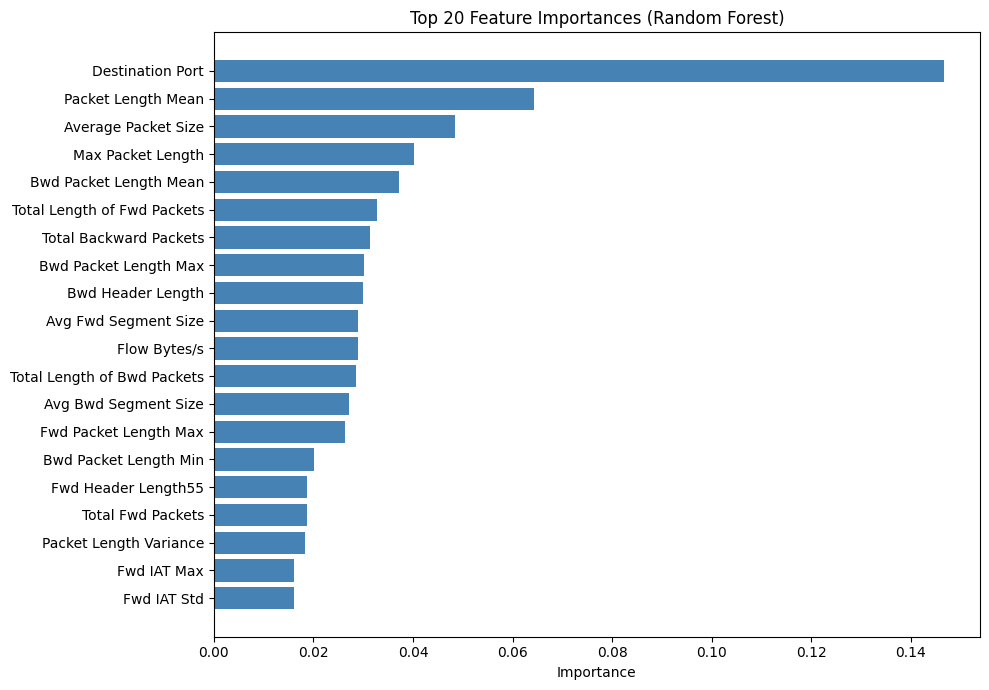

In [15]:
# Top-20 feature importance bar chart
top20 = importance_df.head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20["feature"][::-1], top20["importance"][::-1], color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.savefig("models/feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

Selected 41 / 59 features
                        feature  importance  cumulative
0              Destination Port    0.146572    0.146572
1            Packet Length Mean    0.064290    0.210861
2           Average Packet Size    0.048397    0.259258
3             Max Packet Length    0.040286    0.299544
4        Bwd Packet Length Mean    0.037198    0.336742
5   Total Length of Fwd Packets    0.032791    0.369532
6        Total Backward Packets    0.031283    0.400816
7         Bwd Packet Length Max    0.030120    0.430936
8             Bwd Header Length    0.029988    0.460924
9          Avg Fwd Segment Size    0.028923    0.489847
10                 Flow Bytes/s    0.028903    0.518750
11  Total Length of Bwd Packets    0.028469    0.547218
12         Avg Bwd Segment Size    0.027057    0.574275
13        Fwd Packet Length Max    0.026411    0.600686
14        Bwd Packet Length Min    0.020218    0.620904
15          Fwd Header Length55    0.018800    0.639704
16            Total Fw

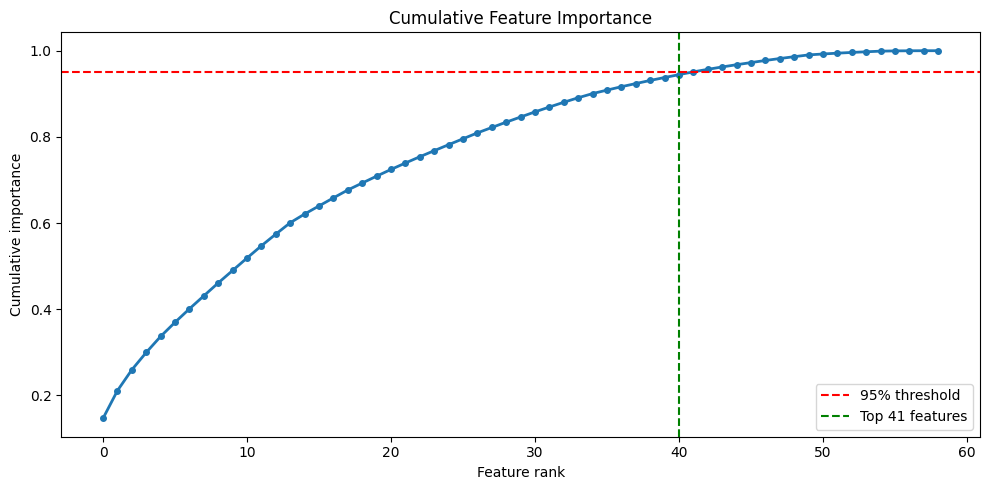

In [16]:
importance_df["cumulative"] = importance_df["importance"].cumsum()
selected_features = importance_df[importance_df["cumulative"] <= 0.95]["feature"].tolist()

print(f"Selected {len(selected_features)} / {len(good_cols)} features")
print(importance_df[["feature", "importance", "cumulative"]])

# Save selected feature names
with open("models/selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)
print(f"\nSaved: models/selected_features.pkl ({len(selected_features)} features)")

# Cumulative importance plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(importance_df)), importance_df["cumulative"], marker="o", markersize=4, linewidth=2)
ax.axhline(0.95, color="red", linestyle="--", label="95% threshold")
ax.axvline(len(selected_features) - 1, color="green", linestyle="--", label=f"Top {len(selected_features)} features")
ax.set_xlabel("Feature rank")
ax.set_ylabel("Cumulative importance")
ax.set_title("Cumulative Feature Importance")
ax.legend()
plt.tight_layout()
plt.savefig("models/cumulative_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Final Feature Assembly — Top Selected Features

In [17]:
assembler_sel = VectorAssembler(
    inputCols=selected_features,
    outputCol="features_raw_sel",
    handleInvalid="skip"
)

scaler_sel = StandardScaler(
    inputCol="features_raw_sel",
    outputCol="features_selected",
    withMean=True,
    withStd=True
)

df2_sel = assembler_sel.transform(df1)
scaler_sel_model = scaler_sel.fit(df2_sel)
df_sel = scaler_sel_model.transform(df2_sel)
scaler_sel_model.write().overwrite().save("models/scaler_selected_features")
print("Saved: models/scaler_selected_features")

print(f"Final: {df_sel.count()} rows x {len(selected_features)} features")

Saved: models/scaler_selected_features
Final: 173193 rows x 41 features


In [18]:
df_sel.limit(5).toPandas().head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,label_index,features_raw_sel,features_selected
0,0,117745832,138,0,0,0,0,0,0.0,0.0,...,10000000,75,13800000.0,8961699.181,30500000,5741713,Normal,4.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.4062428079062757, -0.47598347877402275, -0..."
1,1,97,1,1,0,6,0,0,0.0,0.0,...,0,0,0.0,0.000,0,0,Recon,5.0,"(1.0, 2.0, 3.0, 6.0, 6.0, 0.0, 1.0, 6.0, 20.0,...","[-0.4061701528226809, -0.4709473558139337, -0...."
2,4,87,1,1,0,6,0,0,0.0,0.0,...,0,0,0.0,0.000,0,0,Recon,5.0,"(4.0, 2.0, 3.0, 6.0, 6.0, 0.0, 1.0, 6.0, 20.0,...","[-0.40595218757189633, -0.4709473558139337, -0..."
3,19,52,1,1,2,6,2,2,2.0,0.0,...,0,0,0.0,0.000,0,0,Recon,5.0,"[19.0, 3.333333333, 5.0, 6.0, 6.0, 2.0, 1.0, 6...","[-0.4048623613179736, -0.467589940508047, -0.4..."
4,20,44,1,1,0,6,0,0,0.0,0.0,...,0,0,0.0,0.000,0,0,Recon,5.0,"(20.0, 2.0, 3.0, 6.0, 6.0, 0.0, 1.0, 6.0, 20.0...","[-0.40478970623437877, -0.4709473558139337, -0..."


## 8. Build & Save Feature Pipeline

In [19]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[
    indexer,          # StringIndexer  → label_index
    assembler_sel,    # VectorAssembler → features_raw_sel (40 cols)
    scaler_sel        # StandardScaler  → features_selected
])

# Fit ONLY on training portion
pipeline_model = pipeline.fit(train_fe)
pipeline_model.write().overwrite().save("models/feature_pipeline")
print("Saved: models/feature_pipeline")

final_df = pipeline_model.transform(train_fe).select(
    "features_selected", "label_index", "Label"
)

Saved: models/feature_pipeline


In [20]:
final_df.printSchema()
final_df.show(5, truncate=True)
print("Total rows:", final_df.count())
print("Feature vector size:", len(selected_features))

root
 |-- features_selected: vector (nullable = true)
 |-- label_index: double (nullable = false)
 |-- Label: string (nullable = true)

+--------------------+-----------+------+
|   features_selected|label_index| Label|
+--------------------+-----------+------+
|[-0.4062428079062...|        4.0|Normal|
|[-0.4061701528226...|        5.0| Recon|
|[-0.4059521875718...|        5.0| Recon|
|[-0.4048623613179...|        5.0| Recon|
|[-0.4047897062343...|        5.0| Recon|
+--------------------+-----------+------+
only showing top 5 rows
Total rows: 173193
Feature vector size: 41


## 9. Save Final Dataset to Parquet

In [21]:
final_df.write.mode("overwrite").parquet("data/features/")

## 10. Save Streaming Holdout (Raw)

Save `holdout_raw` with the **same schema as `data/clean/`** (58 raw feature columns + Label).  
The feature pipeline is applied at inference time during streaming — not here.  
This correctly simulates raw network traffic arriving at the stream.

In [22]:
# Save RAW holdout — the feature pipeline is applied at inference time, not here.
# Schema must match data/clean/ so streaming_inference.ipynb can read it correctly.
os.makedirs("data/stream_holdout", exist_ok=True)
holdout_raw.repartition(20).write.mode("overwrite").parquet("data/stream_holdout/")

n_h = holdout_raw.count()
print(f"Saved: data/stream_holdout/  ({n_h:,} raw records, 20 files)")
print()
print("Holdout class distribution:")
holdout_raw.groupBy("Label") \
           .count() \
           .withColumn("pct", F.round(F.col("count") / n_h * 100, 2)) \
           .orderBy("count", ascending=False) \
           .show()

Saved: data/stream_holdout/  (30,519 raw records, 20 files)

Holdout class distribution:


[Stage 278:========================================>             (50 + 17) / 67]

+------------+-----+-----+
|       Label|count|  pct|
+------------+-----+-----+
|  BruteForce| 5840|19.14|
|   WebAttack| 4805|15.74|
|      Botnet| 4746|15.55|
|       Recon| 4638| 15.2|
|      Normal| 4544|14.89|
|    DoS/DDoS| 4430|14.52|
|Infiltration|  759| 2.49|
|  Heartbleed|  757| 2.48|
+------------+-----+-----+



## 10. Stop Spark

In [23]:
spark.stop()